# ELEC/PHYS 450/550 — Programming Assignment 2
# Grover's Algorithm for Constraint Satisfaction

**Spring 2026 — Assoc. Prof. Dr. Mehmet Cengiz Onbaşlı**

---

### Instructions

- Fill in **all** cells marked with `### YOUR CODE HERE ###` and **all** reflection markdown cells marked `[YOUR EXPLANATION HERE]`.
- Do **not** modify cells labelled *DO NOT MODIFY*.
- Before submitting: **Kernel → Restart & Run All** to confirm reproducibility.
- Deliverables: this `.ipynb` file **and** an exported PDF via KUHUB Learn.

### Honor Code

*I hereby certify that I have completed this assignment on my own without any help from anyone else.*

**Name:** `Ahmet Buğra Ertürk` &nbsp;&nbsp;&nbsp; **Student ID:** `0086877`

In [1]:
# ============================================================
# DO NOT MODIFY THIS CELL
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from math import pi, asin, sin, sqrt, floor

print("Setup complete.")

Setup complete.


---
## Background: The Search Problem

You will implement Grover's algorithm to find all 4-bit strings $x \in \{0,1\}^4$ satisfying the predicate
$$f(x) = (x_0 \oplus x_1) \wedge x_2,$$
where $x_0$ is the least significant bit (qubit 0 in Qiskit), $\oplus$ denotes XOR, and $\wedge$ denotes AND.

The search space has $N = 2^4 = 16$ elements.
You should determine the number of marked strings as part of Part A.

**Circuit layout:** your Grover circuit uses **6 qubits** in total:

| Qubits | Role | Initial state |
|--------|------|---------------|
| `q[0]`–`q[3]` | Data register ($x_0$–$x_3$) | $\|0\rangle^{\otimes 4}$ |
| `q[4]` | Computation ancilla | $\|0\rangle$ (must be returned to $\|0\rangle$ after every oracle call) |
| `q[5]` | Phase ancilla | Prepared in $\|-\rangle$ **once** before the Grover iterations; stays in $\|-\rangle$ throughout |

The diffusion operator acts **only on `q[0]`–`q[3]`**. Measurements are taken **only on `q[0]`–`q[3]`**.

---
## Part A — Boolean Oracle via Phase Kickback (35 pts)

### A.1  Theoretical Analysis

Before writing any code, answer the following in the reflection cell below:

1. List all integers in $\{0, \ldots, 15\}$ for which $f(x) = 1$. Show your work by evaluating $(x_0 \oplus x_1)$ and $x_2$ for each candidate.
2. Compute the number of marked states $M$, the initial angle $\theta = \arcsin\sqrt{M/N}$, the optimal iteration count $k^*$, and the theoretical success probability $P(k^*)$. Cite the relevant equations from the Week 7 notes.
3. Explain in words how CNOT and Toffoli gates are used together with a $|-\rangle$ ancilla to implement phase kickback for $f$. Trace through the two cases $f(x) = 0$ and $f(x) = 1$ using Eq. (14)–(15) of the notes.

### Reflection A.1

1. $f(x) = 1$ for $x \in \{5, 6, 13, 14\}$

| Integer | State | $f(x)$ |
|---------|-------|--------|
| 0 | $x = \|0000\rangle$ | $(0 \oplus 0) \wedge 0 = 0$ |
| 1 | $x = \|0001\rangle$ | $(1 \oplus 0) \wedge 0 = 0$ |
| 2 | $x = \|0010\rangle$ | $(0 \oplus 1) \wedge 0 = 0$ |
| 3 | $x = \|0011\rangle$ | $(1 \oplus 1) \wedge 0 = 0$ |
| 4 | $x = \|0100\rangle$ | $(0 \oplus 0) \wedge 1 = 0$ |
| ***<u>5</u>*** | $x = \|0101\rangle$ | $(1 \oplus 0) \wedge 1 = 1$ |
| ***<u>6</u>*** | $x = \|0110\rangle$ | $(0 \oplus 1) \wedge 1 = 1$ |
| 7 | $x = \|0111\rangle$ | $(1 \oplus 1) \wedge 1 = 0$ |
| 8 | $x = \|1000\rangle$ | $(0 \oplus 0) \wedge 0 = 0$ |
| 9 | $x = \|1001\rangle$ | $(1 \oplus 0) \wedge 0 = 0$ |
| 10 | $x = \|1010\rangle$ | $(0 \oplus 1) \wedge 0 = 0$ |
| 11 | $x = \|1011\rangle$ | $(1 \oplus 1) \wedge 0 = 0$ |
| 12 | $x = \|1100\rangle$ | $(0 \oplus 0) \wedge 1 = 0$ |
| ***<u>13</u>*** | $x = \|1101\rangle$ | $(1 \oplus 0) \wedge 1 = 1$ |
| ***<u>14</u>*** | $x = \|1110\rangle$ | $(0 \oplus 1) \wedge 1 = 1$ |
| 15 | $x = \|1111\rangle$ | $(1 \oplus 1) \wedge 1 = 0$ |


2. $M = 4$, $N=16$ and $\theta = \arcsin\sqrt{M/N} \implies \theta = \arcsin 1/2 = \pi/6$

From week 7 notes, the optimal iteration count $k^*$ is:
$$k^* = \left\lfloor \frac{\pi}{4\theta} - \frac{1}{2} \right\rfloor = \left\lfloor \frac{\pi}{4\frac{\pi}{6}} - \frac{1}{2} \right\rfloor = \left\lfloor \frac{3}{2} - \frac{1}{2} \right\rfloor = \left\lfloor 1\right\rfloor = 1$$

and the theoretical success probability $P(k^*)$ is:
$$P(k^*) = \sin^2((2k^*+1)\theta) = \sin^2(3 \times \frac{\pi}{6}) = \sin^2(\frac{\pi}{2}) = 1 \implies P(k^*) = 100\%$$

3. We can use CNOT and Toffoli gate where the target is $|-\rangle$ and works for only $x$ such that $f(x) = 1$. For our case, two CNOT can be used to implement $(x_0 \oplus x_1)$, they both have same target which is `q[4]` but one is controlled by $x_0$, which is `q[0]` and the other one is controlled by $x_1$ which is `q[1]` and then one Toffoli gate can be used to implement $\wedge x_2$ part of our function where it is controlled by $x_2$ which is `q[2]` and `q[4]` which corresponds to $(x_0 \oplus x_1)$ and the target is `q[5]` which is $|-\rangle$. If $f(x) = 1$, `q[5]` will be $-|-\rangle$; otherwise, it will stay same, which means:
$$f(x) = 0 \implies B_f|x\rangle|-\rangle = |x\rangle|- \oplus\ 0\rangle = |x\rangle|-\rangle$$
$$f(x) = 1 \implies B_f|x\rangle|-\rangle = |x\rangle|- \oplus\ 1\rangle = |x\rangle X|-\rangle = -|x\rangle|-\rangle$$

where $B_f|x\rangle|a\rangle = |x\rangle|a \oplus f(x)\rangle$ and $a$ is ancilla qubit.

### A.2  Oracle Implementation

Implement `build_oracle()` below. It must return a `QuantumCircuit` on **6 qubits**
(`q[0]`–`q[3]` = data, `q[4]` = computation ancilla, `q[5]` = phase ancilla)
that implements $\mathcal{O}|x\rangle = (-1)^{f(x)}|x\rangle$
via the compute–phase–uncompute strategy:

1. **Compute** $x_0 \oplus x_1$ into `q[4]` using CNOT gates.
2. **Phase kickback** via a Toffoli: apply `ccx` with `q[4]` and `q[2]` as controls
   and `q[5]` (in $|-\rangle$) as target.
   This marks the data state with phase $-1$ when $f(x)=1$.
3. **Uncompute** `q[4]` back to $|0\rangle$ using the same CNOT gates in reverse.

**Constraint:** do not apply any gate to `q[5]` inside `build_oracle` other than the
single `ccx` above. The phase ancilla is prepared in $|-\rangle$ by the outer Grover
circuit and must remain in $|-\rangle$ after each oracle call.

**Only** `cx` and `ccx` are permitted inside `build_oracle`.

In [2]:
# ----------------------------------------------------------
# A.2  Oracle implementation
# ----------------------------------------------------------

def build_oracle():
    """
    Returns a 6-qubit QuantumCircuit implementing the phase oracle for
    f(x) = (x0 XOR x1) AND x2 via compute-phase-uncompute.

    Qubit layout:
      q[0]-q[3] : data (x0=LSB ... x3=MSB)
      q[4]      : computation ancilla (enters |0>, must exit |0>)
      q[5]      : phase ancilla      (enters |->, exits |->)
    """
    qc = QuantumCircuit(6, name='Oracle')

    qc.cx(0, 4)
    qc.cx(1, 4)
    qc.ccx(4, 2, 5)
    qc.cx(1, 4)
    qc.cx(0, 4)

    return qc


oracle = build_oracle()
print(f"Oracle gate count: {oracle.size()}")
print(oracle.draw(output='text', fold=-1))

Oracle gate count: 5
                              
q_0: ──■───────────────────■──
       │                   │  
q_1: ──┼────■─────────■────┼──
       │    │         │    │  
q_2: ──┼────┼────■────┼────┼──
       │    │    │    │    │  
q_3: ──┼────┼────┼────┼────┼──
     ┌─┴─┐┌─┴─┐  │  ┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├──■──┤ X ├┤ X ├
     └───┘└───┘┌─┴─┐└───┘└───┘
q_5: ──────────┤ X ├──────────
               └───┘          


### A.3  Oracle Verification

Verify that your oracle is correct by checking two properties:

1. **Correct phase flips:** build a 6-qubit test circuit that applies $H^{\otimes 4}$
   to `q[0]`–`q[3]`, prepares `q[5]` in $|-\rangle$ (X then H on `q[5]`), then
   appends the oracle. Use `Statevector` to extract the full state vector.
   For each data integer $x \in \{0,\ldots,15\}$, extract the projection onto the
   $|-\rangle$ subspace and verify that marked states ($f(x)=1$) have a negative
   projection while unmarked states have a positive projection.

2. **Ancilla cleanliness:** in the same statevector, confirm that no amplitude is
   non-negligible at any index where `q[4]` is in state $|1\rangle$.

Print a verification table for all 16 data states.

In [3]:
# ----------------------------------------------------------
# A.3  Oracle verification
# ----------------------------------------------------------

qc = QuantumCircuit(6)

qc.h(range(4))
qc.x(5)
qc.h(5)
qc.compose(oracle, inplace=True)

sv = Statevector.from_instruction(qc)

for x in range(16):
    q5_0 = (0 << 5) | (0 << 4) | x  # |00xxxx>
    q5_1 = (1 << 5) | (0 << 4) | x  # |10xxxx>
    q4_1 = (0 << 5) | (1 << 4) | x  # |01xxxx>
    
    amp_0 = sv.data[q5_0]
    amp_1 = sv.data[q5_1]
    amp_q4_dirty = sv.data[q4_1]
    
    sign_q5 = (amp_0 - amp_1) / np.sqrt(2)
    
    x_bits = [(x >> i) & 1 for i in range(4)]
    f_x = (x_bits[0] ^ x_bits[1]) & x_bits[2]
    
    print(f"x={x:2d}  ({format(x, '04b')})  f(x)={f_x}  phase sign: {'-' if sign_q5 < 0 else '+'}  {'CORRECT' if ((f_x == 1 and sign_q5 < 0) or (f_x == 0 and sign_q5 > 0)) and amp_q4_dirty == 0 else 'INCORRECT'}")

# Suggested output format:
#   x= 0  (0000)  f(x)=0  phase sign: +  CORRECT
#   x= 5  (0101)  f(x)=1  phase sign: -  CORRECT
#   ...

x= 0  (0000)  f(x)=0  phase sign: +  CORRECT
x= 1  (0001)  f(x)=0  phase sign: +  CORRECT
x= 2  (0010)  f(x)=0  phase sign: +  CORRECT
x= 3  (0011)  f(x)=0  phase sign: +  CORRECT
x= 4  (0100)  f(x)=0  phase sign: +  CORRECT
x= 5  (0101)  f(x)=1  phase sign: -  CORRECT
x= 6  (0110)  f(x)=1  phase sign: -  CORRECT
x= 7  (0111)  f(x)=0  phase sign: +  CORRECT
x= 8  (1000)  f(x)=0  phase sign: +  CORRECT
x= 9  (1001)  f(x)=0  phase sign: +  CORRECT
x=10  (1010)  f(x)=0  phase sign: +  CORRECT
x=11  (1011)  f(x)=0  phase sign: +  CORRECT
x=12  (1100)  f(x)=0  phase sign: +  CORRECT
x=13  (1101)  f(x)=1  phase sign: -  CORRECT
x=14  (1110)  f(x)=1  phase sign: -  CORRECT
x=15  (1111)  f(x)=0  phase sign: +  CORRECT


In [4]:
# ============================================================
# AUTO-CHECK A — DO NOT MODIFY
# ============================================================
_qc_test = QuantumCircuit(6)
for _i in range(4):
    _qc_test.h(_i)
_qc_test.x(5)
_qc_test.h(5)
_qc_test = _qc_test.compose(build_oracle())

_sv = Statevector(_qc_test)
_amps = _sv.data
_MARKED = {5, 6, 13, 14}
_tol = 1e-6

# For each data state x: amplitude in the |-> subspace of q[5] is
# proportional to _amps[x] - _amps[x + 32]  (q5=0 component minus q5=1 component)
for _x in range(16):
    _proj = (_amps[_x] - _amps[_x + 32]).real
    if _x in _MARKED:
        assert _proj < -_tol, \
            f"Marked state x={_x}: expected negative projection, got {_proj:.6f}"
    else:
        assert _proj > _tol, \
            f"Unmarked state x={_x}: expected positive projection, got {_proj:.6f}"

# Ancilla cleanliness: q[4] must be |0> in all significant terms
for _idx in range(64):
    if abs(_amps[_idx]) > _tol:
        assert ((_idx >> 4) & 1) == 0, \
            f"Computation ancilla q[4] is dirty at index {_idx} (amp={_amps[_idx]:.4f})"

print("All Part A checks passed!")

All Part A checks passed!


### Reflection A.3

(a) Why does checking the sign of the projection onto the $|-\rangle$ subspace of `q[5]`
    correctly tell you whether the data state was phase-flipped?

If $f(x) = 0$, `q[5]` is $|-\rangle$ and its projection onto $|-\rangle$ is $\langle-|-\rangle = +1$.

If $f(x) = 1$, `q[5]` is $-|-\rangle$ and its projection onto $|-\rangle$ is $\langle-|(-|-\rangle)\rangle = -1$.

(b) Why is uncomputing `q[4]` necessary for a correctly functioning multi-iteration Grover circuit?
    What would go wrong if you skipped the uncomputation?

If we didn't return to the uncomputing `q[4]`, it would stay entangled with `q[0]` and `q[1]`. If we need to change `q[0]`–`q[3]` states during iterations, it will also affect `q[4]` and so `q[5]`. Therefore, we mustn't skip uncomputing.

(c) Why does phase kickback leave `q[5]` in $|-\rangle$ after the Toffoli gate,
    rather than changing its state? Refer to Key Box 5 in the Week 7 notes.

Becuase Toffoli gates apply $X$ gate to `q[5]` if `q[2]`$= 1$ and `q[4]`$= 1$, and $|-\rangle$ is one of the eigenstates of $X$ and its eigenvlaue is $-1$, $X$ does not change the state of the $|-\rangle$, it just changes the phase $X|-\rangle = -|-\rangle$


---
## Part B — Complete Grover Circuit (25 pts)

### B.1  Diffusion Operator

Implement `build_diffusion()`, which returns a 4-qubit `QuantumCircuit` implementing
$D = H^{\otimes 4}(2|0\rangle\langle 0| - I)H^{\otimes 4}$.

From Section 3.3.1 of the notes (Eq. 38), the gate-level decomposition is
$$D = H^{\otimes n} \cdot X^{\otimes n} \cdot \text{MCZ} \cdot X^{\otimes n} \cdot H^{\otimes n},$$
where MCZ is realised as $H$–MCX–$H$ on the last qubit. Use Qiskit's `mcx` method.

In [5]:
# ----------------------------------------------------------
# B.1  Diffusion operator (4 data qubits only)
# ----------------------------------------------------------

def build_diffusion():
    """
    Returns a 4-qubit QuantumCircuit implementing
    D = 2|s><s| - I  (Grover diffusion / inversion about the mean)
    where |s> = H^(x4) |0000>.
    """
    qc = QuantumCircuit(4, name='Diffusion')

    qc.h(range(4))
    qc.x(range(4))
    qc.h(3)
    qc.mcx(list(range(3)), 3)
    qc.h(3)
    qc.x(range(4))
    qc.h(range(4))

    return qc


diff = build_diffusion()
print(f"Diffusion gate count: {diff.size()}")
print(diff.draw(output='text', fold=-1))

Diffusion gate count: 19
     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_2: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_3: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


### B.2  Full Grover Circuit Assembly

Implement `build_grover_circuit(k)`, which assembles the complete Grover circuit
for `k` iterations:

1. Prepare the data register in uniform superposition: $H^{\otimes 4}$ on `q[0]`–`q[3]`.
2. Prepare the phase ancilla in $|-\rangle$: X then H on `q[5]`.
3. Repeat `k` times:
   - append the oracle (all 6 qubits),
   - append the diffusion (acting on qubits 0–3 only, using `compose` with `qubits=[0,1,2,3]`).
4. Add classical measurements on `q[0]`–`q[3]` only.

The function must work correctly for any non-negative integer `k`.

In [6]:
# ----------------------------------------------------------
# B.2  Full Grover circuit
# ----------------------------------------------------------

def build_grover_circuit(k):
    """
    Assemble the complete Grover circuit for k iterations.

    Parameters
    ----------
    k : int  -- number of Grover iterations.

    Returns
    -------
    QuantumCircuit  -- 6-qubit circuit with 4-bit measurement on the data register.
    """
    ### YOUR CODE HERE ###
    qc = QuantumCircuit(6, 4)
    qc.h(range(4))
    qc.x(5)
    qc.h(5)
    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diff, qubits=range(4), inplace=True)
    qc.measure(range(4), range(4))
    return qc


grover_k1 = build_grover_circuit(1)
print(grover_k1.draw(output='text', fold=80))

     ┌───┐                                        ┌───┐┌───┐     ┌───┐┌───┐»
q_0: ┤ H ├──■──────────────────────────────────■──┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤  │                                  │  ├───┤├───┤  │  ├───┤├───┤»
q_1: ┤ H ├──┼─────────■───────────────────■────┼──┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤  │         │            ┌───┐  │    │  ├───┤└───┘  │  ├───┤├───┤»
q_2: ┤ H ├──┼─────────┼─────────■──┤ H ├──┼────┼──┤ X ├───────■──┤ X ├┤ H ├»
     ├───┤  │  ┌───┐  │  ┌───┐  │  ├───┤  │    │  └───┘     ┌─┴─┐├───┤├───┤»
q_3: ┤ H ├──┼──┤ H ├──┼──┤ X ├──┼──┤ H ├──┼────┼────────────┤ X ├┤ H ├┤ X ├»
     └───┘┌─┴─┐└───┘┌─┴─┐└───┘  │  └───┘┌─┴─┐┌─┴─┐          └───┘└───┘└───┘»
q_4: ─────┤ X ├─────┤ X ├───────■───────┤ X ├┤ X ├─────────────────────────»
     ┌───┐├───┤     └───┘     ┌─┴─┐     └───┘└───┘                         »
q_5: ┤ X ├┤ H ├───────────────┤ X ├────────────────────────────────────────»
     └───┘└───┘               └───┘                                        »

### B.3  Run the Optimal Grover Search

Run your Grover circuit with the optimal $k^*$ you derived in Part A
using `AerSimulator` with 8192 shots.
Store the measurement counts in `counts_optimal` and the empirical success probability
(fraction of shots on a marked state) in `p_exp_optimal`.

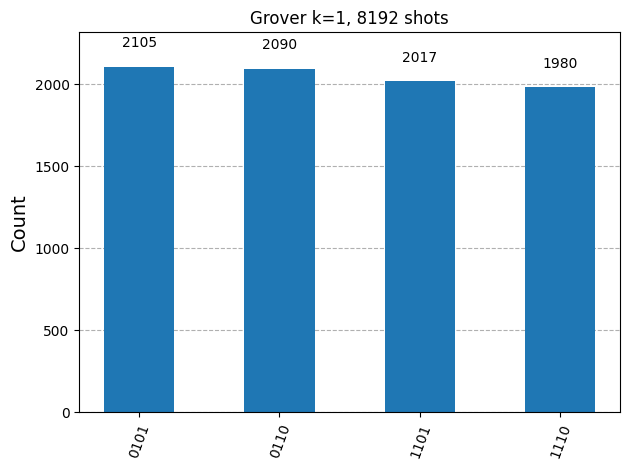

Empirical success probability: 1.0000


In [7]:
# ----------------------------------------------------------
# B.3  Run optimal Grover
# ----------------------------------------------------------

k_star = 1
sim = AerSimulator()
qc = build_grover_circuit(k_star)
counts_optimal = sim.run(transpile(qc, sim), shots=8192).result().get_counts()
p_exp_optimal = sum(c/8192 for s, c in counts_optimal.items() if s in ['0101', '0110', '1101', '1110'])

# Required variables:
#   k_star         : int   -- optimal iteration count
#   counts_optimal : dict  -- measurement counts from AerSimulator
#   p_exp_optimal  : float -- empirical success probability

display(plot_histogram(counts_optimal, title=f"Grover k={k_star}, 8192 shots"))
print(f"Empirical success probability: {p_exp_optimal:.4f}")

In [8]:
# ============================================================
# AUTO-CHECK B — DO NOT MODIFY
# ============================================================
assert isinstance(counts_optimal, dict), "counts_optimal must be a dict"
assert isinstance(p_exp_optimal, float), "p_exp_optimal must be a float"
assert p_exp_optimal > 0.90, \
    f"Empirical success probability {p_exp_optimal:.3f} is too low (expected > 0.90)"

# Qiskit bitstrings are MSB-left: '0101' means q3=0,q2=1,q1=0,q0=1 -> int=5
_MARKED_BS = {'0101', '0110', '1101', '1110'}
_total = sum(counts_optimal.values())
_on_marked = sum(counts_optimal.get(bs, 0) for bs in _MARKED_BS)
assert _on_marked / _total > 0.90, \
    "Most shots must fall on the 4 marked states {5, 6, 13, 14}"

print(f"k* = {k_star}")
print(f"Empirical P(k*) = {p_exp_optimal:.4f}")
print("All Part B checks passed!")

k* = 1
Empirical P(k*) = 1.0000
All Part B checks passed!


### Reflection B

(a) Describe the sequence of operations in your Grover circuit and the purpose of each stage.
    In particular, explain why the phase ancilla is prepared in $|-\rangle$ only once (not inside the oracle)
    and why it remains in $|-\rangle$ after every oracle call.

Initilization:
    
1. Apply $H^{\oplus4}$ to data qubits `q[0]`-`q[3]` to create superposition.
    
2. Apply $XH$ to `q[5]` to create $|-\rangle$ state which is the eigenstate corresponding to eigenvalue $-1$ of $X$ gate. We use this state for ancilla instead of others because if we use other eigenstate of $X$ which is $|+\rangle$ corresponding to the eigenvalue $+1$, when we apply $X$ gate to this qubit, its phase won't change due to its eigenvalue. We cannot use the states other than eigenstates since if we use other ones, the state will change completely not but in our case only global phase changes and it doesn't affect the measurement.

Iteration:

1. **Oracle** marks `q[5]` with changing phase from $|-\rangle$ to $-|-\rangle$ if $f(x) = 1$ with Toffoli gate which apply $X$ gate to `q[5]`. Otherwise, it remains $|-\rangle$. For both cases, we don't need to prepare `q[5]` again and again because it remains as $|-\rangle$ with different phases which is one of the eigenstates of $X$.

2. **Diffusion** performs a reflection about the average amplitude, converting the phase differences into magnitude differences.

Measurement: 

1. Collapses the superposition to observe the probability 4-bit strings.

(b) Explain why the diffusion operator is applied to the 4 data qubits only, even though
    the oracle spans all 6 qubits. What role do qubits `q[4]` and `q[5]` play during the
    diffusion step?

1. The 4 data qubits are the qubits that we create superposition and marked `q[5]` if $f(x) = 1$ with changing the phase.

2. The uncomputing `q[4]` have to be stay uncomputing to prevent the entanglement because if it is entangled, ancilla qubit will change when we apply diffusion to first 4 qubit and it may changes the marked states.

3. `q[5]` keeps our phase and shows the marked states. Because of the phase kickback, its phase changes the phase of all state and diffusion can see the amplitude of first 4 qubit as negative with help from `q[5]`.

(c) Your empirical $P_{\mathrm{exp}}(k^*)$ should match the theoretical value closely but
    may not be exactly equal. Identify the source(s) of the discrepancy.

* Gate errors,

* Measurement errors,

* Decoherence,

* Simulation precision.


---
## Part C — Overshoot and Iteration Sensitivity (25 pts)

### C.1  Theoretical Success Probability

Compute the theoretical success probability
$P_k = \sin^2\!\bigl((2k+1)\theta\bigr)$
for $k = 0, 1, 2, 3, 4, 5$ using your value of $\theta$ from Part A.
Store the results in a list `p_theory` (index $k$ gives $P_k$).
Also store the angle $\theta$ (in radians) in a variable called `theta`.

In [9]:
# ----------------------------------------------------------
# C.1  Theoretical P(k)
# ----------------------------------------------------------

theta = asin(sqrt(4/16))
p_theory = [sin((2*k + 1)*theta)**2 for k in range(6)]

# Required: theta (float, radians), p_theory (list of 6 floats)

print(f"theta = {theta:.6f} rad = {theta*180/pi:.4f} deg")
print()
print(f"{'k':>3}  {'angle (deg)':>12}  {'P_theory':>12}")
print("-" * 35)
for k, p in enumerate(p_theory):
    angle_deg = (2*k + 1) * theta * 180 / pi
    print(f"{k:>3}  {angle_deg:>12.3f}  {p:>12.6f}")

theta = 0.523599 rad = 30.0000 deg

  k   angle (deg)      P_theory
-----------------------------------
  0        30.000      0.250000
  1        90.000      1.000000
  2       150.000      0.250000
  3       210.000      0.250000
  4       270.000      1.000000
  5       330.000      0.250000


### C.2  Experimental Success Probability

Run the Grover circuit for each $k \in \{0, 1, 2, 3, 4, 5\}$ on `AerSimulator`
with 8192 shots. Record the empirical success probability
(fraction of shots on marked states) in a list `p_exp` indexed by $k$.

In [10]:
# ----------------------------------------------------------
# C.2  Experimental P(k) for k = 0..5
# ----------------------------------------------------------

p_exp = []

for k in range(6):
    qc = build_grover_circuit(k)
    counts = sim.run(transpile(qc, sim), shots=8192).result().get_counts()
    p_k = sum(c/8192 for s, c in counts.items() if s in ['0101', '0110', '1101', '1110'])
    p_exp.append(p_k)

# Required: p_exp (list of 6 floats)

print(f"{'k':>3}  {'P_theory':>12}  {'P_exp':>12}  {'|error|':>10}")
print("-" * 45)
for k in range(6):
    print(f"{k:>3}  {p_theory[k]:>12.6f}  {p_exp[k]:>12.6f}  {abs(p_theory[k]-p_exp[k]):>10.6f}")

  k      P_theory         P_exp     |error|
---------------------------------------------
  0      0.250000      0.242798    0.007202
  1      1.000000      1.000000    0.000000
  2      0.250000      0.255615    0.005615
  3      0.250000      0.252075    0.002075
  4      1.000000      1.000000    0.000000
  5      0.250000      0.252197    0.002197


### C.3  Overshoot Plot

Produce a single figure showing:
- A smooth curve of $P_k = \sin^2((2k+1)\theta)$ plotted continuously over $k \in [0, 5]$.
- Discrete markers for $P_{\mathrm{exp}}(k)$ at integer $k = 0, \ldots, 5$.
- A vertical dashed line at $k = k^*$.
- Proper axis labels, title, and legend.

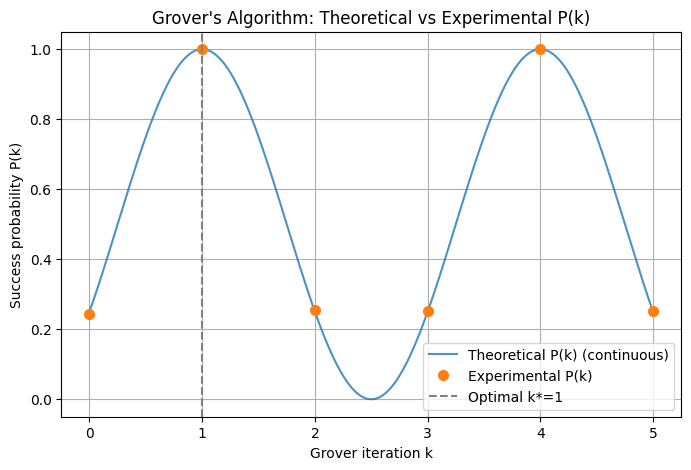

In [11]:
# ----------------------------------------------------------
# C.3  Overshoot plot
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))
k_dense = np.linspace(0, 5, 400)
p_dense = [sin((2*k + 1)*theta)**2 for k in k_dense]
plt.plot(k_dense, p_dense, '-', color='C0', alpha=0.8, label='Theoretical P(k) (continuous)')
plt.plot(range(6), p_exp, 'o', color='C1', markersize=7, label='Experimental P(k)')
plt.axvline(k_star, color='gray', linestyle='--', label=f'Optimal k*={k_star}')
plt.xticks(range(6))
plt.xlabel('Grover iteration k')
plt.ylabel('Success probability P(k)')
plt.title('Grover\'s Algorithm: Theoretical vs Experimental P(k)')
plt.legend()
plt.grid()
plt.show()

In [12]:
# ============================================================
# AUTO-CHECK C — DO NOT MODIFY
# ============================================================
assert len(p_theory) == 6, "p_theory must have 6 entries"
assert len(p_exp) == 6, "p_exp must have 6 entries"

_expected = [sin((2*k+1)*theta)**2 for k in range(6)]
for _k in range(6):
    assert abs(p_theory[_k] - _expected[_k]) < 1e-4, \
        f"p_theory[{_k}]={p_theory[_k]:.4f} expected {_expected[_k]:.4f}"

assert p_exp[1] > 0.90, f"p_exp[1]={p_exp[1]:.3f} should be > 0.90"
assert p_exp[2] < p_exp[1], \
    f"Overshoot not detected: p_exp[2]={p_exp[2]:.3f} should be less than p_exp[1]={p_exp[1]:.3f}"

print("All Part C checks passed!")

All Part C checks passed!


### Reflection C

(a) Examine the sequence $P_0, P_1, P_2, \ldots$ from your `p_theory` list.
    Describe the pattern. Is it periodic? What is the period, and why does periodicity arise
    in amplitude amplification?

Yes, it is periodic. The pattern is $0.25$, $1$, $0.25$. For our case, $P = \sin^2((2k+1)\theta) = \sin^2((2k+1)\frac{\pi}{6})$ and it repeats itself $P(k)=P(k+3)$ which means the perion is 3. Amplitude amplification is just a unitary rotation, so it is periodic.

(b) Interpret the geometric picture (Section 3.4) to explain why $k = k^* + 1$ gives lower
    success than $k = k^*$. What has happened to the state vector in the
    $|A\rangle$–$|B\rangle$ plane?

* At $k = k^* = 1$: The state vector is perfectly aligned with the $|B\rangle$ which is $90^\circ$ for our case.

* At $k = k^*+1 = 2$: The rotation continues by another $2\theta=60^\circ$ The state vector now sits at $90^\circ+60^\circ=150^\circ$ and the value of its projection on $|B\rangle$ will be $1/2$ so $P=1/4$.


(c) The value $P_0 = M/N = 1/4$ corresponds to zero Grover iterations.
    Interpret this: what does measuring after zero iterations correspond to, and
    why does it already give 25% success?

* At $k = 0$: $P = \sin^2((2k+1)\theta) = \sin^2(\frac{\pi}{6}) = 1/4 = 25\%$

(d) Do your experimental values $P_{\mathrm{exp}}(k)$ match the theory closely?
    Identify and explain any deviations.

It matches almost perfectly, there is some deviations for only the cases $P \neq 1$ and it can be caused by noise due to decoherence, measurement errors etc.


---
## Part D — Scaling Verification (15 pts)

### D.1  Grover Query Complexity vs. $N$

Verify the $O(\sqrt{N})$ query-complexity scaling empirically.
For each $n \in \{3, 4, 5, 6, 7\}$, run an $n$-qubit Grover search for a
**single marked state** (target $t = 2^{n-1} - 1$ in decimal).

For this part you may use any oracle construction strategy.

For each $n$, compute:
- $k^*_{\text{theory}} = \lfloor (\pi/4)\sqrt{N} \rfloor$
- $P_{\text{theory}}(k^*) = \sin^2\!\bigl((2k^*+1)\theta\bigr)$ with $\theta = \arcsin(1/\sqrt{N})$

Run your circuit with $k^*_{\text{theory}}$ iterations and 4096 shots; record $P_{\text{exp}}$.

Store results in `scaling_results`, a list of dicts with keys
`'n'`, `'N'`, `'k_theory'`, `'p_theory'`, `'p_exp'`.

In [13]:
# ----------------------------------------------------------
# D.1  Scaling experiment (n = 3..7)
# ----------------------------------------------------------

def grover_single_target(n, target, k, shots=4096):
    """
    Build and run an n-qubit Grover circuit for a single marked target integer.

    Parameters
    ----------
    n      : int  -- number of data qubits
    target : int  -- the single marked integer in {0, ..., 2^n - 1}
    k      : int  -- number of Grover iterations
    shots  : int  -- number of measurement shots

    Returns
    -------
    float : empirical P_exp (fraction of shots on the target)
    """
    qc = QuantumCircuit(n + 1, n)
    
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    
    for _ in range(k):
        target_bin = format(target, f'0{n}b')[::-1]
        
        for i, bit in enumerate(target_bin):
            if bit == '0': qc.x(i)
            
        qc.mcx(list(range(n)), n)
        
        for i, bit in enumerate(target_bin):
            if bit == '0': qc.x(i)
            
        qc.barrier()
        
        qc.h(range(n))
        qc.x(range(n))
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)
        qc.h(n-1)
        qc.x(range(n))
        qc.h(range(n))
        qc.barrier()

    qc.measure(range(n), range(n))
    
    sim = AerSimulator()
    t_qc = transpile(qc, sim)
    result = sim.run(t_qc, shots=shots).result()
    counts = result.get_counts()
    
    target_str = format(target, f'0{n}b')
    return counts.get(target_str, 0) / shots


scaling_results = []

for n in [3, 4, 5, 6, 7]:
    # Compute k_theory, p_theory, run experiment, append dict to scaling_results
    N = 2**n
    M = 1
    
    theta = np.arcsin(np.sqrt(M/N))
    k_star = int(np.round(np.pi / (4 * theta) - 0.5))
    p_theory = np.sin((2 * k_star + 1) * theta)**2
    
    p_exp = grover_single_target(n, target=1, k=k_star)
    
    scaling_results.append({
        'n': n,
        'N': N,
        'k_theory': k_star,
        'p_theory': p_theory,
        'p_exp': p_exp
    })

print(f"{'n':>4}  {'N':>6}  {'k*_theory':>12}  {'P_theory':>10}  {'P_exp':>10}")
print("-" * 52)
for r in scaling_results:
    print(f"{r['n']:>4}  {r['N']:>6}  {r['k_theory']:>12}  "
          f"{r['p_theory']:>10.4f}  {r['p_exp']:>10.4f}")

   n       N     k*_theory    P_theory       P_exp
----------------------------------------------------
   3       8             2      0.9453      0.9441
   4      16             3      0.9613      0.9600
   5      32             4      0.9992      0.9993
   6      64             6      0.9966      0.9973
   7     128             8      0.9956      0.9934


### D.2  Scaling Plot

Produce a **log-log plot** of $k^*_{\text{theory}}$ vs. $N$ for $n = 3,\ldots,7$.
Overlay a reference line $k = c\sqrt{N}$ fitted (by least squares in log-space)
to your theoretical data. Also overlay a reference line $k_{\text{classical}} = N/2$
(the expected classical query count) for comparison. Label all curves.

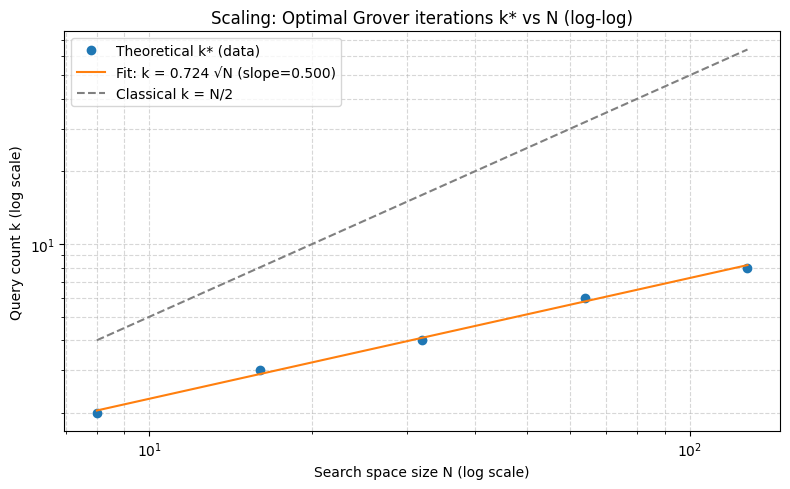

In [14]:
# ----------------------------------------------------------
# D.2  Log-log scaling plot
# ----------------------------------------------------------

N = np.array([r['N'] for r in scaling_results], dtype=float)
k_theory = np.array([r['k_theory'] for r in scaling_results], dtype=float)

logN = np.log(N)
logk = np.log(k_theory)

coeffs = np.polyfit(logN, logk, 1)
b_fit, a_fit = coeffs[0], coeffs[1]
c_fit = np.exp(a_fit)

N_dense = np.linspace(N.min(), N.max(), 200)
k_sqrt_ref = c_fit * np.sqrt(N_dense)
k_classical = N_dense / 2.0

plt.figure(figsize=(8, 5))
plt.plot(N, k_theory, 'o', color='C0', label='Theoretical k* (data)')
plt.plot(N_dense, k_sqrt_ref, '-', color='C1', label=f'Fit: k = {c_fit:.3f} √N (slope={b_fit:.3f})')
plt.plot(N_dense, k_classical, '--', color='gray', label='Classical k = N/2')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Search space size N (log scale)')
plt.ylabel('Query count k (log scale)')
plt.title('Scaling: Optimal Grover iterations k* vs N (log-log)')
plt.legend()
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# AUTO-CHECK D — DO NOT MODIFY
# ============================================================
assert len(scaling_results) == 5, "scaling_results must have 5 entries (n=3..7)"
for _r in scaling_results:
    assert _r['p_exp'] > 0.70, \
        f"n={_r['n']}: P_exp={_r['p_exp']:.3f} is too low (expected > 0.70)"

# Verify sqrt-N scaling: when N quadruples, k* should approximately double
_ks = [r['k_theory'] for r in scaling_results]
for _i in range(len(_ks) - 2):
    _ratio = _ks[_i + 2] / _ks[_i]
    assert 1.5 < _ratio < 2.8, (
        f"k* ratio {_ratio:.2f} between n={scaling_results[_i]['n']} and "
        f"n={scaling_results[_i+2]['n']} does not match sqrt(4)=2 scaling"
    )

print("All Part D checks passed!")

All Part D checks passed!


### Reflection D

(a) From your log-log plot, what is the empirical slope of the $k^*$ vs $N$ curve?
    Does it match the theoretical slope of $1/2$ (i.e., $k^* \propto \sqrt{N}$)?

It is almost same as the theoretical slope which is $1/2$

(b) Compare the Grover and classical reference curves. At $n=7$ ($N=128$),
    how many times fewer queries does Grover use?
    How does this ratio change as $N$ grows?

* Grover needs only 8 iteration for this case but a classical computer would expected 64 iteration as average.

* Grover uses 8 times fewer queries than the classical average.

* As $N$ grows, the ratio chages with $\sqrt{N}$. This shows us the quantum advantage.

(c) The BBBV theorem (Section 3.7.1) proves that $\Omega(\sqrt{N})$ oracle queries are
    necessary for any quantum algorithm solving unstructured search.
    What does this imply about whether your implementation could be improved?
    Could a cleverer circuit design ever achieve $O(N^{1/3})$ queries?

Since the theorem proves that $\Omega(\sqrt{N})$ queries are strictly necessary, it implies that our implementation is already optimal.

No. A cleverer circuit design can never achieve $\Omega(N^{1/3})$ because it would violate the BBBV theorem.


---
## Submission Checklist

Before submitting, verify the following:

- [*] Your name and student ID are filled in at the top of the notebook.
- [*] All four parts completed: code cells filled in, auto-checks pass, reflection cells written.
- [*] The notebook runs from top to bottom without errors (**Kernel → Restart & Run All**).
- [*] You have exported the notebook as a PDF.
- [*] Both the `.ipynb` and `.pdf` files are submitted on KUHUB Learn.

**Good luck!**